# Color ProcessingCovers HSV and LAB color processing, color masks, green-screen replacement, dominant-color clustering, and hue histograms.

## Import libraries

In [1]:
# import Open CV library
import cv2

import matplotlib.pyplot as plt
import numpy as np

## Color Filtering
In many computer vision applications like object tracking, segmentation, or color detection — we need to isolate specific colors from an image (for example, detect a red ball or a green object).

However, using the BGR color space can be unreliable, because it is sensitive to lighting changes.
Instead, we use the **HSV color space**


Text(0.5, 1.0, 'Tracked Green')

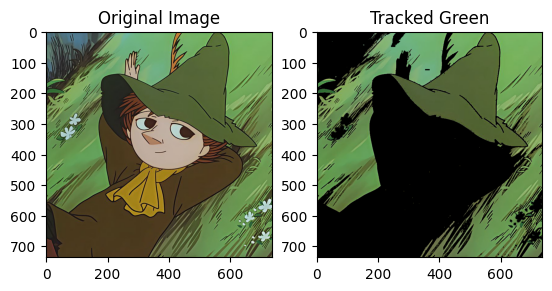

In [ ]:
img = cv2.imread("images/Snufkin.jpg")
hsv_img = cv2.cvtColor(img,cv2.COLOR_BGR2HSV) # covert to hsv

# track green
lower_blue = np.array([30,50,90])
upper_blue = np.array([70,255,255])

mask = cv2.inRange(hsv_img,lower_blue,upper_blue) 

result = cv2.bitwise_and(hsv_img,hsv_img,mask=mask)
output = cv2.cvtColor(result,cv2.COLOR_HSV2RGB) # covert to RGB

plt.subplot(121);plt.imshow(img[:,:,::-1]);plt.title("Original Image")
plt.subplot(122);plt.imshow(output);plt.title("Tracked Green")

when detecting red, we encounter a special situation  we must define two HSV ranges instead of one.
(0-10) and (170-180)

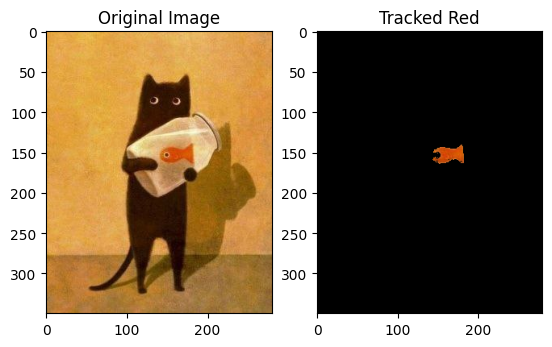

In [78]:
img = cv2.imread("images/Cat.jpg")
hsv_img = cv2.cvtColor(img,cv2.COLOR_BGR2HSV) # covert to hsv

# mask1 0-10
lower_red = np.array([0,190,180])
upper_red = np.array([14,255,255])
mask1 = cv2.inRange(hsv_img,lower_red,upper_red) 

# mask2 170-180
lower_red = np.array([170,190,180])
upper_red = np.array([179,255,255])
mask2 = cv2.inRange(hsv_img,lower_red,upper_red) 

mask = mask1+mask2

result = cv2.bitwise_and(hsv_img,hsv_img,mask=mask)
output = cv2.cvtColor(result,cv2.COLOR_HSV2RGB) # covert to RGB

plt.subplot(121);plt.imshow(img[:,:,::-1]);plt.title("Original Image")
plt.subplot(122);plt.imshow(output);plt.title("Tracked Red")

mask = mask1 + mask2

### LAB color space
LAB color space goes a step further by being perceptually uniform — meaning it better matches how humans perceive color differences.

- The L channel represents lightness only, so we can adjust brightness without affecting color information.

- The A and B channels represent chromaticity (color), which helps separate color details from lighting variations.

- LAB is less sensitive to illumination and **more consistent under changing lighting conditions** compared to HSV.

### Green Screen Removal


### HSV

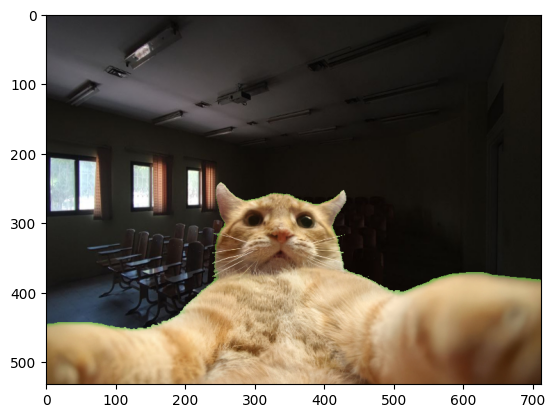

In [ ]:
img = cv2.imread("images/Greenscr.png")
hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV) # covert to HSV
h,w,_ = img.shape
green_h_value = hsv[0,0][0] # H value of (0,0) pixel , which is our green pixel

bg = cv2.imread("images/classroom.jpg")
bg = cv2.resize(bg,(w,h))

lower_green = np.array([green_h_value-10,50,50])
upper_green = np.array([green_h_value+10,255,255])

mask_green = cv2.inRange(hsv,lower_green,upper_green)
mask_not_green = cv2.bitwise_not(mask_green)

foreground = cv2.bitwise_and(hsv,hsv,mask=mask_not_green)
foreground = cv2.cvtColor(foreground,cv2.COLOR_HSV2BGR)
background = cv2.bitwise_and(bg,bg,mask=mask_green)

output = cv2.add(foreground,background)

plt.imshow(output[:,:,::-1])


### LAB

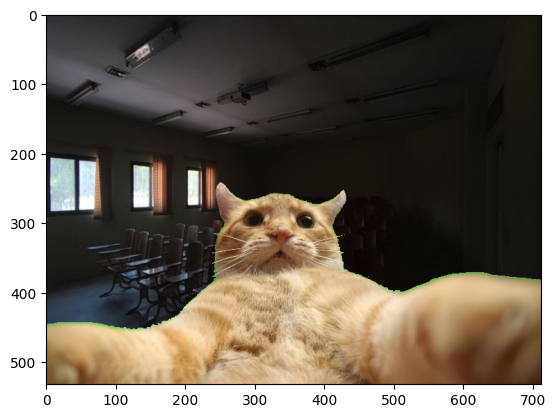

In [124]:
img = cv2.imread("images/Greenscr.png")
LAB = cv2.cvtColor(img,cv2.COLOR_BGR2LAB) # covert to LAB
h,w,_ = img.shape

bg = cv2.imread("images/classroom.jpg")
bg = cv2.resize(bg,(w,h))

a_channel = LAB[:,:,1]
_, mask_not_green = cv2.threshold(a_channel,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
mask_not_green = cv2.bitwise_not(mask_green)

foreground = cv2.bitwise_and(img,img,mask=mask_not_green)
foreground = cv2.cvtColor(foreground,cv2.COLOR_BGR2RGB)
background = cv2.bitwise_and(bg,bg,mask=mask_green)
background = cv2.cvtColor(background,cv2.COLOR_BGR2RGB)


output = cv2.add(foreground,background)

plt.imshow(output)

## K-Means Clustering
In image analysis, we often want to find the dominant colors — the main hues that make up an image.
To extract these dominant colors, one of the most effective methods is clustering, particularly using the [K-Means algorithm](https://docs.opencv.org/4.x/de/d4d/tutorial_py_kmeans_understanding.html).

function: <code>_, labels, centers = cv2.kmeans(pixels, K, bestLabels, criteria, attempts, flags)</code>
- <code>pixels</code> : It should be of <code>np.float32</code> data type and <code>reshaped</code>
- <code>k</code> : number of clusters
- <code>criteria</code> : Termination Criteria ,it should be a tuple of 3 parameters criteria = <code>(type ,max_iter ,epsilon)</code>:
    - <code>cv2.TERM_CRITERIA_EPS</code> : Stop when the cluster centers move less than a certain accuracy (epsilon).
    - <code>cv2.TERM_CRITERIA_MAX_ITER</code> : Stop after a fixed number of iterations (max count).
    - <code>(+)</code> : when either of above conditions met.
- <code>attempts</code> : Number of re-runs.
- <code>flags</code> : How initial cluster centers are chosen (random, PP, etc.).

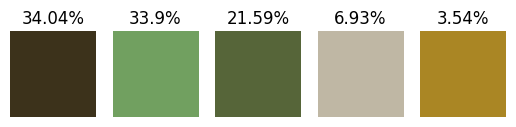

In [8]:
img = cv2.imread("images/Snufkin.jpg",cv2.IMREAD_COLOR_RGB)
pixels = img.reshape((-1,3))
pixels = np.float32(pixels)

k = 5

# criteria = ( type, max_iter = 20 , epsilon = 1.0 )
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER ,20 ,1.0)

_ ,labels ,centers = cv2.kmeans(pixels ,k ,None ,criteria ,10 ,cv2.KMEANS_RANDOM_CENTERS)

# convert to uint8
centers = np.uint8(centers)

# Count each cluster’s frequency
unique, counts = np.unique(labels, return_counts=True)
freq = counts / np.sum(counts)

# Sort colors by frequency
sorted_idx = np.argsort(-freq)
centers = centers[sorted_idx]
freq = freq[sorted_idx]

palette = np.zeros((300, 300, 3), np.uint8)

for i in range(k):
    plt.subplot(1,k,i+1)
    palette[:] = centers[i]
    plt.imshow(palette)
    plt.title(f"{round((freq[i]*100),2)}%")
    plt.axis("off")

## HSV Histogram
finding the dominant colors with HSV histogram


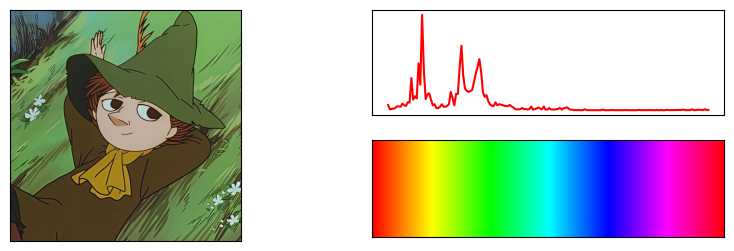

In [14]:

h_value = np.linspace(0, 179, dtype='uint8', num=180)
block = np.array([h_value]*50)
s_value = np.ones_like(block, dtype='uint8')*255
v_value = np.ones_like(block, dtype='uint8')*255


hsv_bar = cv2.merge([block, s_value, v_value])
hsv_bar = cv2.cvtColor(hsv_bar, cv2.COLOR_HSV2RGB)

img = cv2.imread("images/Snufkin.jpg",cv2.IMREAD_COLOR_RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
hue_hist = cv2.calcHist([hsv], [0], None, [180], [0, 180])


plt.figure(figsize=[10,3]);
plt.subplot(121);plt.imshow(img);plt.xticks([]);plt.yticks([]);
plt.subplot(222);plt.plot(hue_hist, color='red');plt.xticks([]);plt.yticks([]);
plt.subplot(224);plt.imshow(hsv_bar);plt.xticks([]);plt.yticks([]);